In [219]:
import numpy as np
import deepRD.tools.trajectoryTools as trajectoryTools
import matplotlib.pyplot as plt

In [374]:
systemType = 'dimer' # 'bistable', 'dimer'

# Datasets directory
localDirectory = f"/group/ag_cmb/scratch/maojrs/stochasticClosure/{systemType}/boxsize5/benchmark/"

# Loading trajectories.
n_trajs = 100
fnums = np.random.choice(2500, n_trajs, replace=False)
dataset=None

for f_num in fnums:
    try:
        ds = trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)[np.newaxis, :]
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = np.concatenate((dataset, ds), axis=0)
        
print('Trajectories loaded.')

Trajectories loaded.


In [375]:
#datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)]
print(dataset.shape)

if systemType=='bistable':
    
    timesteps = dataset[0, :, 0]
    dt = round(timesteps[1] - timesteps[0], 5)
    
    q = dataset[:, :, 1:4]
    
    x = dataset[:, :, 1]
    x_dot = dataset[:, :, 4]

elif systemType=='dimer':

    timesteps = dataset[0, ::2, 0]
    dt = round(timesteps[1] - timesteps[0], 5)
    
    q_1 = dataset[:, ::2, 1:4]
    q_2 = dataset[:, 1::2, 1:4]

    v_1 = dataset[:, ::2, 4:7]
    v_2 = dataset[:, 1::2, 4:7]

    # relative position, velocity
    q = q_1 - q_2
    v = v_1 - v_2

    # 1D relative distance and relative velocity
    x = np.linalg.norm(q, axis=2)
    x_dot = np.linalg.norm(v, axis=2)
    
print(x.shape, x_dot.shape, dt)

(100, 20000, 11)
(100, 10000) (100, 10000) 0.05


In [376]:
def calculateForce_bistable(x, minimaDist, kconstants, scale):
    
    force_0 = - kconstants[0] * 4 * x[0] * (x[0]**2 - minimaDist**2)/minimaDist**4
    force_1 = - kconstants[1] * 2 * x[1]
    force_2 = - kconstants[2] * 2 * x[2]

    force = np.concatenate((force_0[np.newaxis,:], force_1[np.newaxis,:], force_2[np.newaxis,:]), axis=0)
    return scalefactor * np.transpose(force, (1,2,0))

def calculateForce_dimer(relPos, x0, rad, scale, a):
    '''
    relPos - relative position vector, with shape (n_trajs, n_timesteps, 3)
    '''
    x = np.linalg.norm(relPos, axis=0)
    arg = (x - (x0 + rad)) / rad
    dVdr = 4.0 * (1 - arg**2) * arg / rad - a/x
    
    force_0 = dVdr * relPos[0] / x
    force_1 = dVdr * relPos[1] / x
    force_2 = dVdr * relPos[2] / x
    
    force = np.concatenate((force_0[np.newaxis,:], force_1[np.newaxis,:], force_2[np.newaxis,:]), axis=0)
    
    return scale * np.transpose(force, (1,2,0))

# Calculating array of forces for all trajectories and all timesteps. 
# F = -gradU, this is required to calculate correlation function.

if systemType=='bistable':

    minimaDist = 1.5
    kconstants = np.array([1.0, 1.0, 1.0])
    scalefactor = 1
    
    forces = calculateForce_bistable(np.transpose(q, (2,0,1)), minimaDist, kconstants, scalefactor)

elif systemType=='dimer':
    
    particleDiameter = 0.5
    x0 = 1.0*particleDiameter # location of first minima
    rad = 1.0*particleDiameter # half the distance between minimas
    scalefactor = 2
    a=1
    
    forces = calculateForce_dimer(np.transpose(q, (2,0,1)), x0, rad, scalefactor, a)
    
forces.shape

(100, 10000, 3)

In [377]:
# Calculating correlation matrices

C_xx = np.average(x_dot[:, 0][:, np.newaxis]*x_dot, axis=0)
C_xx_N = C_xx/C_xx[0] # normalised 

C_Ux = np.average(x[:, 0][:, np.newaxis]*(-forces[:, :, 0]), axis=0)
C_Ux_N = C_Ux/C_Ux[0]

C_xx.shape, C_Ux.shape

((10000,), (10000,))

In [378]:
def extract_G(timesteps, x, dt, C_xx, C_Ux):
    '''
    Function that implements the numerical scheme to calculate G (the running integral of memory kernel)
    '''

    n_steps = len(timesteps)
    G = np.zeros(n_steps)
    
    alpha = 2/(dt*C_xx[0])
    beta = C_Ux[0]/C_xx[0]

    for i in range(1, n_steps):

        G[i] = alpha*( C_Ux[i] - beta*C_xx[i] - dt * np.sum( G[1:i] * C_xx[1:i][::-1] ) )

    return G    

In [379]:
G = extract_G(timesteps, x, dt, C_xx_N, C_Ux_N)

# Simple numerical differentiation to get Memory Kernel
MemoryKernel = np.gradient(G, dt) 

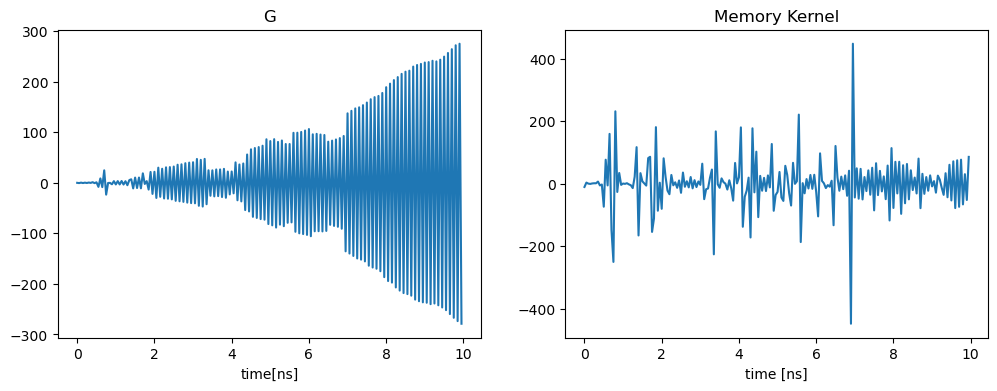

In [382]:
n_plot = 200

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(timesteps[:n_plot]-timesteps[0], G[:n_plot])
ax1.set_xlabel('time[ns]')
ax1.set_title('G')

ax2.plot(timesteps[:n_plot]-timesteps[0], MemoryKernel[:n_plot])
ax2.set_xlabel('time [ns]')
ax2.set_title('Memory Kernel')

plt.show()